# Contando possibilidades

No dia a dia, muitas situações envolvem escolher entre diferentes combinações possíveis. Em alguns casos, conseguimos listar todas as possibilidades com facilidade.

Mas será que isso sempre funciona? Vamos começar com um exemplo simples.

Você vai fazer uma refeição em uma lanchonete e tem 2 opções de lanches salgados (🍔 Hambúrguer e 🍕 Pizza) e 3 opções de sobremesas (🍦 Sorvete, 🍩 Donut e 🎂 Bolo), quantos cardápios diferentes você consegue montar?

**a)** Liste todos os cardápios possíveis.

In [1]:
%%html
<p><b>Sua lista:</b></p>
<textarea style="width: 100%; height: 100px; border: 1px solid #ccc; border-radius: 4px;"></textarea>

**b)** Quantos cardápios diferentes você encontrou?

Após listar as combinações, observe sua resposta.

**c)** Sua lista está organizada de alguma forma?

**d)** Existe o risco de você ter esquecido alguma combinação ou repetido outra?

Quando o número de possibilidades é pequeno, listar pode parecer suficiente. No entanto, sem organização, fica fácil se confundir, repetir casos ou deixar possibilidades de fora.

Uma maneira de evitar esse problema é organizar as combinações de forma sistemática.

**e)** Reorganize sua lista agrupando os cardápios de acordo com cada opção de lanche salgado.

In [2]:
%%html
<p><b>Sua lista organizada:</b></p>
<textarea style="width: 100%; height: 100px; border: 1px solid #ccc; border-radius: 4px;"></textarea>

```{admonition} Veja a lista organizada
:class: dropdown

* 🍔🍦 (Hambúrguer com Sorvete)
* 🍔🍩 (Hambúrguer com Donut)
* 🍔🎂 (Hambúrguer com Bolo)
_____________________________

* 🍕🍦 (Pizza com Sorvete)
* 🍕🍩 (Pizza com Donut)
* 🍕🎂 (Pizza com Bolo)

Até agora, trabalhamos com uma situação em que o número de possibilidades era pequeno. Mas o que acontece quando aumentamos a quantidade de opções disponíveis?

O simulador abaixo permite alterar a quantidade de lanches salgados e sobremesas e observar automaticamente todos os cardápios possíveis.
Ao utilizá-lo, observe como a lista é organizada.

Tente responder às seguintes perguntas:

a)	O que acontece quando acrescentamos um novo lanche salgado?

b)	O que acontece quando acrescentamos uma nova sobremesa?

c)	Como os cardápios aparecem agrupados na lista?

d)	Existe algum padrão que se repete?

Explore diferentes configurações e registre suas observações antes de continuar.

O que você percebeu sobre a organização dos cardápios?

In [3]:
import json
from IPython.display import HTML, display

# Listas de opções disponíveis
lanches = [
    ["🍔", "Hambúrguer"],
    ["🍕", "Pizza"],
    ["🌭", "Cachorro-Quente"],
    ["🥪", "Sanduíche"],
    ["🌮", "Taco"],
    ["🍟", "Batata Frita"],
    ["🍙", "Bolinho de Arroz"],
    ["🍝", "Macarrão"]
]

sobremesas = [
    ["🍦", "Sorvete"],
    ["🍧", "Raspadinha"],
    ["🍩", "Donut"],
    ["🎂", "Bolo"],
    ["🍰", "Fatia de Bolo"],
    ["🧁", "Cupcake"],
    ["🥞", "Panqueca"],
    ["🍫", "Chocolate"],
    ["🍪", "Cookie"]
]

# Conversão das listas do Python para JavaScript
lanches_json = json.dumps(lanches, ensure_ascii=False)
sobremesas_json = json.dumps(sobremesas, ensure_ascii=False)

# Identificador do simulador
# Ajuda a evitar conflitos caso existam outros elementos interativos na página
simulador_id = "simulador-cardapios"

codigo_interativo = f"""
<div
    id="{simulador_id}"
    style="
        font-family: system-ui, sans-serif;
        max-width: 600px;
        margin: 20px auto;
        padding: 20px;
        border: 1px solid #e1e4e6;
        border-radius: 8px;
        background-color: #f8f9fa;
    "
>
    <h3 style="margin-top: 0; color: #24292e;">
        🍽️ Simulador de Cardápios
    </h3>

    <div style="margin-bottom: 15px;">
        <label
            style="
                display: inline-block;
                width: 180px;
                font-weight: bold;
            "
        >
            Lanches salgados:
            <span class="valor-lanches">2</span>
        </label>

        <input
            type="range"
            class="slide-lanches"
            min="1"
            max="{len(lanches)}"
            value="2"
            style="width: 200px; vertical-align: middle;"
        >
    </div>

    <div style="margin-bottom: 20px;">
        <label
            style="
                display: inline-block;
                width: 180px;
                font-weight: bold;
            "
        >
            Sobremesas:
            <span class="valor-sobremesas">3</span>
        </label>

        <input
            type="range"
            class="slide-sobremesas"
            min="1"
            max="{len(sobremesas)}"
            value="3"
            style="width: 200px; vertical-align: middle;"
        >
    </div>

    <div
        class="lista-combinacoes"
        style="
            max-height: 350px;
            overflow-y: auto;
            background-color: white;
            padding: 12px 16px;
            border: 1px solid #e1e4e6;
            border-radius: 4px;
            font-size: 0.95em;
            line-height: 1.6;
        "
    ></div>
</div>

<script>
(function() {{
    const simulador = document.getElementById("{simulador_id}");

    const dadosLanches = {lanches_json};
    const dadosSobremesas = {sobremesas_json};

    const slideLanches =
        simulador.querySelector(".slide-lanches");

    const slideSobremesas =
        simulador.querySelector(".slide-sobremesas");

    const valorLanches =
        simulador.querySelector(".valor-lanches");

    const valorSobremesas =
        simulador.querySelector(".valor-sobremesas");

    const lista =
        simulador.querySelector(".lista-combinacoes");

    function atualizar() {{
        const quantidadeLanches =
            parseInt(slideLanches.value);

        const quantidadeSobremesas =
            parseInt(slideSobremesas.value);

        valorLanches.textContent = quantidadeLanches;
        valorSobremesas.textContent = quantidadeSobremesas;

        let conteudo = "";

        for (
            let indiceLanche = 0;
            indiceLanche < quantidadeLanches;
            indiceLanche++
        ) {{
            const emojiLanche =
                dadosLanches[indiceLanche][0];

            const nomeLanche =
                dadosLanches[indiceLanche][1];

            /*
            Cada lanche inicia um novo bloco.
            A linha aparece antes de todos os blocos,
            exceto o primeiro.
            */
            if (indiceLanche > 0) {{
                conteudo += `
                    <hr style="
                        border: none;
                        border-top: 1px solid #d0d7de;
                        margin: 16px 0;
                    ">
                `;
            }}

            conteudo += `
                <div style="
                    font-weight: 600;
                    color: #24292e;
                    margin-bottom: 6px;
                ">
                </div>
            `;

            for (
                let indiceSobremesa = 0;
                indiceSobremesa < quantidadeSobremesas;
                indiceSobremesa++
            ) {{
                const emojiSobremesa =
                    dadosSobremesas[indiceSobremesa][0];

                const nomeSobremesa =
                    dadosSobremesas[indiceSobremesa][1];

                conteudo += `
                    <div style="
                        padding: 3px 0 3px 18px;
                        color: #3b4248;
                    ">
                        ${{emojiLanche}} ${{nomeLanche}}
                        com
                        ${{emojiSobremesa}} ${{nomeSobremesa}}
                    </div>
                `;
            }}
        }}

        lista.innerHTML = conteudo;
    }}

    slideLanches.addEventListener("input", atualizar);
    slideSobremesas.addEventListener("input", atualizar);

    atualizar();
}})();
</script>
"""

display(HTML(codigo_interativo))

Percebeu como a lista ficou extensa? Imagine se fossem 20 lanches e 15 sobremesas! O computador gerou uma lista longa em milésimos de segundo. Mas imagine se você tivesse que fazer isso à mão toda vez que o número de opções aumentasse... seria inviável, não é?

Será que existe uma maneira de descobrir a quantidade total de possibilidades sem precisar escrever o nome de cada uma delas? Vamos voltar ao nosso primeiro exemplo e representá-lo usando um diagrama de árvore.

O diagrama de árvore organiza as mesmas possibilidades que a lista, mas de uma maneira diferente. Em vez de observar apenas as combinações prontas, podemos acompanhar o processo de construção de cada cardápio.

Será que essa nova representação revela algum padrão?

No diagrama, cada ramificação representa uma escolha. Ao percorrer a árvore do início até uma de suas extremidades, formamos um caminho completo, correspondente a um dos cardápios possíveis.

Vamos fixar em 2 opções de lanches salgados e ver o que acontece quando mudamos a quantidade de opções de sobremesa. Use o controle deslizante para ver o que acontece.


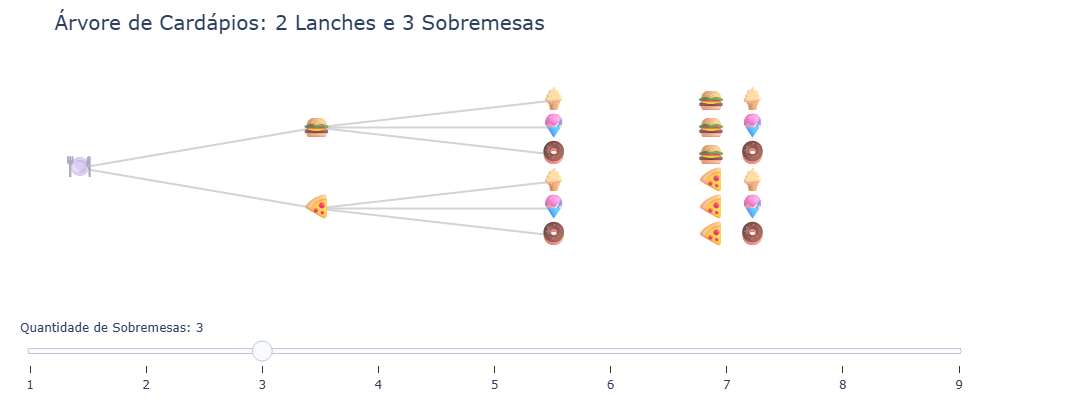

In [2]:
import plotly.graph_objects as go

def criar_arvore_interativa(num_lanches=2):
    # Nossas listas de emojis
    lanches = ["🍔", "🍕", "🌭", "🥪", "🌮", "🍟", "🍙", "🍝"]
    sobremesas = ["🍦", "🍧", "🍩", "🎂", "🍰", "🧁", "🥞", "🍫", "🍪"]
    
    n = min(num_lanches, len(lanches))
    
    # 1. Função interna que calcula as coordenadas da árvore para um número 'm' de sobremesas
    def calcular_dados_da_arvore(m):
        labels = ["🍽️"]
        edges = [(0, k) for k in range(1, n+1)]
        
        for i in range(n): 
            labels.append(lanches[i])
            
        current_index = n + 1
        children = {i: [] for i in range(1, n+1)}
        
        # Lista temporária para guardar a string da combinação final
        resultados_labels = []
        
        for parent in range(1, n+1):
            for j in range(m):
                # Adiciona APENAS a sobremesa no nó da árvore
                labels.append(sobremesas[j]) 
                # Guarda o resultado final para plotar depois
                resultados_labels.append(f"{lanches[parent-1]} {sobremesas[j]}") 
                
                edges.append((parent, current_index))
                children[parent].append(current_index)
                current_index += 1
                
        total_nodes = len(labels)
        total_elements = total_nodes + len(resultados_labels)
        
        Xn, Yn = [0] * total_elements, [0] * total_elements
        total_leaves = n * m
        
        # --- Posicionamento Y Absoluto para não deformar no slider ---
        resultado_idx = total_nodes
        
        # Folhas (Sobremesas) e Resultados Finais
        for i, child in enumerate(range(n+1, total_nodes)):
            # Posição do nó da sobremesa
            Xn[child] = 4
            Yn[child] = -i + (total_leaves - 1)/2.0
            
            # Posição do resultado final (nó fantasma mais à direita)
            Xn[resultado_idx] = 5.5
            Yn[resultado_idx] = Yn[child] # Mantém na mesma linha da sobremesa
            labels.append(resultados_labels[i])
            resultado_idx += 1
            
        # Galhos (Lanches) ficam na média da altura de seus filhos
        for parent in range(1, n+1):
            Xn[parent] = 2
            Yn[parent] = sum(Yn[c] for c in children[parent]) / m
            
        # Raiz (Início) fica na média da altura dos lanches
        Xn[0] = 0
        Yn[0] = sum(Yn[p] for p in range(1, n+1)) / n
        
        # Coordenadas das linhas (as linhas ligam apenas até a sobremesa)
        Xe, Ye = [], []
        for u, v in edges:
            Xe += [Xn[u], Xn[v], None]
            Ye += [Yn[u], Yn[v], None]
            
        # Altura dinâmica da tela e limites do eixo Y
        altura_pixels = max(400, total_leaves * 40 + 150)
        limite_y = [-total_leaves/2 - 1, total_leaves/2 + 1]
        
        return Xe, Ye, Xn, Yn, labels, altura_pixels, limite_y

    # ==========================================
    # 2. Configurando o Plotly com a Árvore Inicial (m=3)
    # ==========================================
    initial_m = 3
    Xe_0, Ye_0, Xn_0, Yn_0, labels_0, height_0, y_range_0 = calcular_dados_da_arvore(initial_m)

    fig = go.Figure()
    
    # Trace 0: Linhas (Galhos)
    fig.add_trace(go.Scatter(
        x=Xe_0, y=Ye_0, mode='lines', 
        line=dict(color='lightgray', width=2), hoverinfo='none'
    ))
    
    # Trace 1: Textos (Emojis da Árvore + Resultados Finais)
    fig.add_trace(go.Scatter(
        x=Xn_0, y=Yn_0, mode='text', 
        text=labels_0, textfont=dict(size=24), hoverinfo='none'
    ))

    # ==========================================
    # 3. Criando as "cenas" do Slider (de 1 a 9 sobremesas)
    # ==========================================
    steps = []
    for m_val in range(1, 10):
        Xe, Ye, Xn, Yn, labels, th, y_range = calcular_dados_da_arvore(m_val)
        
        step = dict(
            method="update",
            args=[
                {"x": [Xe, Xn], "y": [Ye, Yn], "text": [None, labels]},
                {
                    "title.text": f"Árvore de Cardápios: {n} Lanches e {m_val} Sobremesas",
                    "height": th,
                    "yaxis.range": y_range
                }
            ],
            label=str(m_val)
        )
        steps.append(step)

    sliders = [dict(
        active=initial_m - 1,
        currentvalue={"prefix": "Quantidade de Sobremesas: "},
        pad={"t": 40},
        steps=steps
    )]

    # Finalizando a renderização
    fig.update_layout(
        sliders=sliders,
        showlegend=False,
        plot_bgcolor='white',
        height=height_0,
        margin=dict(l=20, r=120, t=60, b=50),
        # Ampliei o eixo X para 7.5 para garantir que a combinação final caiba perfeitamente na tela
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.5, 7.5]),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=y_range_0),
        title=dict(text=f"Árvore de Cardápios: {n} Lanches e {initial_m} Sobremesas", font=dict(size=20))
    )

    fig.show()

# Chama a função para testar!
criar_arvore_interativa(num_lanches=2)

Explore o diagrama e observe como cada cardápio é construído.

Altere a quantidade de sobremesas no simulador e observe os caminhos formados na árvore. Para cada configuração, complete a tabela.

Na terceira coluna, registre o total de cardápios representados na árvore.


In [7]:
from IPython.display import HTML, display

tabela_investigacao = """
<div class="investigacao-arvore">

    <div class="tabela-responsiva">
        <table class="tabela-padrao">
            <thead>
                <tr>
                    <th>Quantidade de<br>lanches salgados</th>
                    <th>Quantidade de<br>sobremesas</th>
                    <th>Total de<br>cardápios</th>
                </tr>
            </thead>

            <tbody>
                <tr>
                    <td>2</td>
                    <td>1</td>
                    <td>
                        <input
                            type="number"
                            min="0"
                            aria-label="Total de cardápios com uma sobremesa"
                        >
                    </td>
                </tr>

                <tr>
                    <td>2</td>
                    <td>2</td>
                    <td>
                        <input
                            type="number"
                            min="0"
                            aria-label="Total de cardápios com duas sobremesas"
                        >
                    </td>
                </tr>

                <tr>
                    <td>2</td>
                    <td>3</td>
                    <td>
                        <input
                            type="number"
                            min="0"
                            aria-label="Total de cardápios com três sobremesas"
                        >
                    </td>
                </tr>

                <tr>
                    <td>2</td>
                    <td>4</td>
                    <td>
                        <input
                            type="number"
                            min="0"
                            aria-label="Total de cardápios com quatro sobremesas"
                        >
                    </td>
                </tr>

                <tr>
                    <td>2</td>
                    <td>5</td>
                    <td>
                        <input
                            type="number"
                            min="0"
                            aria-label="Total de cardápios com cinco sobremesas"
                        >
                    </td>
                </tr>
            </tbody>
        </table>
    </div>

</div>

<style>
.investigacao-arvore {
    width: 100%;
    margin: 20px 0;
    font-family: Arial, sans-serif;
}

.orientacao-tabela {
    margin-bottom: 16px;
    line-height: 1.5;
}

.tabela-responsiva {
    width: 100%;
    overflow-x: auto;
}

.tabela-padrao {
    width: 100%;
    min-width: 480px;
    border-collapse: collapse;
    background-color: white;
}

.tabela-padrao th,
.tabela-padrao td {
    border: 1px solid #b8b8b8;
    padding: 12px;
    text-align: center;
    vertical-align: middle;
}

.tabela-padrao th {
    background-color: #f1f3f5;
    font-weight: 600;
}

.tabela-padrao tbody tr:nth-child(even) {
    background-color: #fafafa;
}

.tabela-padrao input {
    width: 75px;
    padding: 8px;
    border: 1px solid #8f8f8f;
    border-radius: 6px;
    font-size: 16px;
    text-align: center;
    background-color: white;
}

.tabela-padrao input:focus {
    outline: 2px solid #5271ff;
    border-color: transparent;
}
</style>
"""

display(HTML(tabela_investigacao))


Quantidade delanches salgados,Quantidade desobremesas,Total decardápios
2,1,
2,2,
2,3,
2,4,
2,5,


a) O que você percebeu ao comparar o número de sobremesas com a quantidade de possibilidades que surge para cada lanche?

b) Como o total de cardápios se relaciona com o número de lanches e o número de sobremesas?

c) Sem construir uma nova árvore, qual seria o total de cardápios com 2 lanches e 6 sobremesas?

```{admonition} Compare suas observações
:class: dropdown
A montagem de cada cardápio acontece em duas etapas:

1. escolher um dos **2 lanches salgados**;
2. escolher uma das **6 sobremesas**.

Para cada opção de lanche salgado, podemos escolher qualquer uma das 6 sobremesas. Portanto, a quantidade total de cardápios é:

 2⋅6=12
 
Assim, podemos descobrir o total de possibilidades multiplicando a quantidade de opções disponíveis em cada etapa.


## Do diagrama de árvore à multiplicação

No simulador anterior, observamos o que acontece quando há 2 opções de lanche salgado e 6 opções de sobremesa. Vamos agora representar essa mesma situação por meio de um diagrama de árvore.

Observe como a árvore é construída. Primeiro, aparecem as 2 opções de lanche salgado. Em seguida, a partir de cada uma delas, surgem 6 ramificações, correspondentes às opções de sobremesa.

Cada caminho completo da árvore representa um cardápio diferente.

**[Inserir aqui o GIF da árvore 2x6]**

A montagem de cada cardápio acontece em duas etapas:

1. escolher um dos 2 lanches salgados;
2. escolher uma das 6 sobremesas.

Para cada opção de lanche salgado, podemos escolher qualquer uma das 6 sobremesas. Por isso, o número total de cardápios é:

$2 \cdot 6=12$

Não é necessário contar os caminhos da árvore um a um. Podemos determinar o total multiplicando a quantidade de opções disponíveis em cada etapa.

**Acrescentando uma nova escolha**

Até agora, cada cardápio era formado por duas escolhas: um lanche salgado e uma sobremesa.

Suponha agora que cada cardápio também deva incluir uma bebida. A lanchonete oferece 2 opções de bebida: 🥤 Suco e 🧃 Chá gelado.

Assim, cada cardápio será formado por:

1. um lanche salgado;
2. uma sobremesa;
3. uma bebida.

Continuamos com 2 opções de lanche salgado e 6 opções de sobremesa e acrescentamos 2 opções de bebida.

Antes de observar a nova árvore, responda:

a) Quantas etapas são necessárias para formar um cardápio?

b) Quantas opções estão disponíveis em cada etapa?

c) Qual multiplicação você acredita que representa o número total de cardápios?

Agora, observe como a árvore é construída. A partir de cada combinação de lanche salgado e sobremesa, surgem duas novas ramificações, uma para cada opção de bebida.

**[Inserir aqui o GIF da árvore 2x6x2]**

Após observar a animação, responda:

Qual multiplicação representa o número total de cardápios?


:::{dropdown} Compare sua conclusão

A formação do cardápio acontece em três etapas:

- há 2 possibilidades para escolher o lanche salgado;
- para cada uma delas, há 6 possibilidades para escolher a sobremesa;
- para cada sequência já formada, há 2 possibilidades para escolher a bebida.

Por isso, o número total de cardápios é:

$2 \cdot 6 \cdot 2=24$

Assim como no exemplo anterior, multiplicamos a quantidade de opções disponíveis em cada etapa.

**Refazer vídeos e acrescentar junto ao texto acima**

:::{figure} ./videos/DiagramaArvore.mp4
Animação mostrando a construção de um diagrama de árvore para o princípio multiplicativo.
:::

:::{figure} ./videos/DiagramaArvore2x3x2.mp4
Animação mostrando a construção de um diagrama de árvore para o princípio multiplicativo.
:::

Esses exemplos nos levam ao chamado Princípio Fundamental da contagem, ou Princípio Multiplicativo.

:::{important} Princípio Fundamental da Contagem

Se um processo ou evento é composto por uma sequência de $n$ decisões sucessivas, em que:

- a 1ª decisão pode ser tomada de $x_1$ maneiras;
- a 2ª decisão pode ser tomada de $x_2$ maneiras (uma vez que a primeira decisão foi tomada);

$\vdots$

- e assim sucessivamente, até a $n$-ésima decisão, que pode ser tomada de $x_n$ maneiras (independentemente das escolhas feitas nas etapas anteriores).

O número total de maneiras de se tomar todas as decisões é:

$$
x_1 \cdot x_2 \cdot \ldots \cdot x_n
$$

Agora é com você: use o Princípio Multiplicativo para resolver as questões a seguir.

## Exercícios

> **1. Mala de viagem**
>
> Você vai viajar e está arrumando sua mala. Nela, você colocou 4 calças, 8 camisetas e 2 sapatos diferentes. Considerando que você precisa escolher uma calça, uma camiseta e um sapato para formar o 'look' do dia, quantas opções diferentes de conjuntos de roupa você poderá formar?

> **2. Caderno personalizado**
> 
> Em uma papelaria, um caderno personalizado é montado escolhendo:
> - uma entre 4 cores de capa;
> - uma entre 3 estampas;
> - um entre 2 tipos de espiral.
>   
> **a)** Quantas etapas formam o processo de personalização?
> 
> **b)** Escreva a multiplicação correspondente.
> 
> **c)** Quantos cadernos diferentes podem ser produzidos?

---

> **3. Criação de personagens**
> 
> Em um jogo, cada personagem é criado escolhendo:
> - uma entre 4 espécies;
> - uma entre 5 classes;
> - uma entre 3 habilidades especiais;
> - uma entre 2 cores de uniforme.
> 
> **a)** Quantas escolhas sucessivas são realizadas?
> 
> **b)** Escreva a multiplicação que representa o total de personagens.
> 
> **c)** Quantos personagens diferentes podem ser criados?

---

> **4. Caminhos até a escola**
> 
> Para ir de sua casa até a escola, Júlia precisa passar por uma praça.
> - De sua casa até a praça, existem 3 caminhos diferentes.
> - Da praça até a escola, existem 5 caminhos diferentes.
> 
> **a)** Represente as duas etapas do percurso.
> 
> **b)** Quantos percursos diferentes Júlia pode fazer de sua casa até a escola, passando pela praça?

---

> **5. Códigos de identificação**
> 
> Uma escola cria códigos para identificar os armários dos estudantes. Cada código é formado, nessa ordem, por:
> 1. uma letra escolhida entre A, B, C e D;
> 2. um algarismo escolhido entre 1, 2, 3, 4 e 5;
> 3. um símbolo escolhido entre ★, ● e ▲.
> 
> **a)** Quantas opções existem em cada posição do código?
> 
> **b)** Escreva a multiplicação que representa o número total de códigos.
> 
> **c)** Quantos códigos diferentes podem ser formados?

---

> **6. Coloração de um mapa**
> 
> Um mapa é formado por quatro regiões dispostas em sequência, como representado abaixo:
> 
> **Inserir aqui o mapa com quatro regiões dispostas em sequência.**
> 
> Duas regiões que possuem uma fronteira comum não podem receber a mesma cor. Para colorir o mapa, estão disponíveis 5 cores diferentes.
> 
> **a)** De quantas maneiras podemos escolher a cor da região A?
> 
> **b)** Depois de colorir a região A, quantas cores podem ser escolhidas para a região B?
> 
> **c)** Após colorir a região B, quantas opções de cor existem para a região C? Explique por que a região C pode ter a mesma cor da região A.
> 
> **d)** Escreva a multiplicação que representa o número total de maneiras de colorir o mapa.
> 
> **e)** Determine quantas colorações diferentes podem ser feitas.
> 